In [1]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, f1_score
from pubmed_loader import PubMedQAData
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

We plan to use 3 text representation approaches: 
- TF-IDF 
- BioWordVec
- PubMedBERT

## TF-IDF(Axis 1) + Logistic Regression Baseline(Axis 2)


This notebook implements the a simple pipeline: sparse TF-IDF text representation combined with Logistic Regression classification. It serves as the baseline against which BioWordVec and PubMedBERT results will be compared.

**Attention:** This is just an example of how we might do the experiment next, and it doesn't represent the final pipeline. If there is any deficiency in this document, please add it.

### 1. Import and Label definition

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from preprocessing import preprocess_tfidf

In [3]:
LABEL_NAMES = {0: "no", 1: "maybe", 2: "yes"}

### 2. Medical Stop Words
Standard English stop word lists (e.g. sklearn's `ENGLISH_STOP_WORDS`) remove words like *"no"*, *"not"*, and *"without"* — which are semantically critical in medical text. For example, *"no significant improvement"* and *"significant improvement"* carry opposite meanings. We manually retain these negation words.

In [4]:
# Set stopwords
MEDICAL_KEEP  = {"no", "not", "without", "never", "neither", "nor"}
med_stopwords = list(ENGLISH_STOP_WORDS - MEDICAL_KEEP)

### 3. Data Loading

In [5]:
data = PubMedQAData("data")

train_texts, train_labels = preprocess_tfidf(data.train_set, use_mesh=True)
dev_texts, dev_labels = preprocess_tfidf(data.dev_set,   use_mesh=True)
test_texts, test_labels = preprocess_tfidf(data.test_set,  use_mesh=True)

print(f"train: {len(train_texts)} samples")
print(f"dev:   {len(dev_texts)}   samples")
print(f"test:  {len(test_texts)}  samples")

train: 450 samples
dev:   50   samples
test:  500  samples


### 4. TF-IDF Vectorisation

In [6]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),         # unigram + bigram
    stop_words=med_stopwords,   # Set stopwords
    #lowercase=True,            # default
    token_pattern=r"\b[a-zA-Z\-]\w*\b",  # Keep the hyphen (Maybe not?)
    max_features=50000,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(train_texts)
X_dev   = vectorizer.transform(dev_texts)
X_test  = vectorizer.transform(test_texts)

In [7]:
print(f"TF-IDF Matrix dimensions: {X_train.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

TF-IDF Matrix dimensions: (450, 50000)
Vocabulary size: 50000


### 5. Logistic Regression

In [8]:
clf = LogisticRegression(
    class_weight="balanced",    # Handling category imbalance
    max_iter=1000,
    # C=1.0,
    # solver="saga",
)
 
clf.fit(X_train, train_labels)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

### 6. Evaluation

In [9]:
y_pred = clf.predict(X_test)

In [10]:
def evaluate(y_pred, y_true, split_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    print(f"\n── {split_name} ──")
    print(f"Accuracy: {acc:.4f}  Macro-F1: {f1:.4f}")
    print(classification_report(
        y_true, y_pred,
        # target_names=["no", "maybe", "yes"]
    ))
    # return y_pred

In [11]:
# dev_preds  = evaluate(,  dev_labels,  "Dev_set")
evaluate(y_pred, test_labels, "Test_set")


── Test_set ──
Accuracy: 0.5280  Macro-F1: 0.3403
              precision    recall  f1-score   support

           0       0.57      0.75      0.65       276
           1       0.42      0.34      0.38       169
           2       0.00      0.00      0.00        55

    accuracy                           0.53       500
   macro avg       0.33      0.36      0.34       500
weighted avg       0.46      0.53      0.48       500



g:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
g:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
g:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
print("\nError samples (top 5)")
test_items = list(data.test_set.items())
errors = [
    (pmid, sample, test_labels[i], y_pred[i])
    for i, (pmid, sample) in enumerate(test_items)
    if test_labels[i] != y_pred[i]
]
 
for pmid, sample, true, pred in errors[:5]:
    print(f"\nPMID: {pmid}")
    print(f"Question : {sample['QUESTION']}")
    print(f"True     : {LABEL_NAMES[true]}")
    print(f"Predicted: {LABEL_NAMES[pred]}")


Error samples (top 5)

PMID: 24481006
Question : Should cavitation in proximal surfaces be reported in cone beam computed tomography examination?
True     : no
Predicted: maybe

PMID: 8165771
Question : Ultrasound in squamous cell carcinoma of the penis; a useful addition to clinical staging?
True     : no
Predicted: maybe

PMID: 22680064
Question : Can third trimester ultrasound predict the presentation of the first twin at delivery?
True     : no
Predicted: maybe

PMID: 22902073
Question : Estimated fetal weight by ultrasound: a modifiable risk factor for cesarean delivery?
True     : no
Predicted: maybe

PMID: 15041506
Question : Is fear of anaphylactic shock discouraging surgeons from more widely adopting percutaneous and laparoscopic techniques in the treatment of liver hydatid cyst?
True     : no
Predicted: maybe


In [13]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrix(y_true, y_pred, ax=None):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "maybe", "yes"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

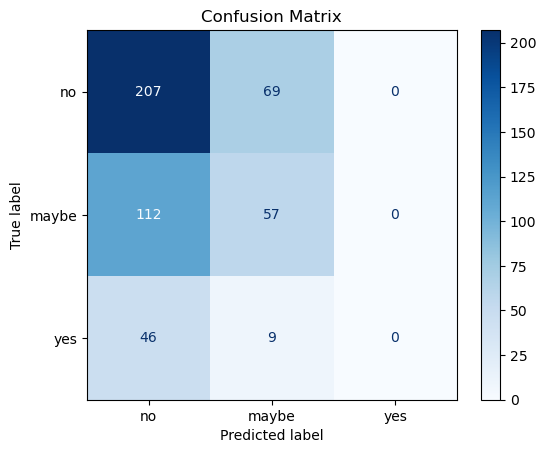

In [14]:
plot_confusion_matrix(test_labels, y_pred, ax=None)